# Week 4 · Day 3 — Feature Engineering, Cross-Validation & Model Comparison

**Dataset:** UCI Adult (Census Income)  
**Goal:** Engineer ≥6 principled features, integrate them into a leakage-free pipeline, cross-validate 3 models, run statistical tests, and select features for tomorrow's hyperparameter tuning.

> **Leakage rule:** All features use only **current-row data**. No target encoding.

---
## Task 1 — Create & Justify Engineered Features

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score, make_scorer
)
from scipy.stats import wilcoxon

RANDOM_STATE = 42

# Load & clean dataset (same pipeline as Day 1 & 2)
adult = fetch_openml('adult', version=2, as_frame=True)
df_raw = adult.frame.copy()
df_raw = df_raw.replace('?', np.nan)
df_raw['target'] = (df_raw['class'].astype(str).str.strip() == '>50K').astype(int)
df_raw = df_raw.drop(columns=['class'])

print(f"Raw shape: {df_raw.shape}  |  Positive rate: {df_raw['target'].mean():.4f}")

Raw shape: (48842, 15)  |  Positive rate: 0.2393


In [2]:
# ============================================================
# FEATURE ENGINEERING FUNCTION
# Applied inside the pipeline via FunctionTransformer so it runs
# independently on each train/validation fold -- no leakage.
# ============================================================
def add_engineered_features(df):
    """
    Adds 6 engineered features. All use only current-row data.
    Returns a new DataFrame (does not mutate the input).
    """
    df = df.copy()

    # --- EF1: age_bucket ---
    # WHY: Income has a non-linear, hump-shaped relationship with age.
    # Young workers (<30) are entry-level; mid-career (30-55) peak earnings;
    # older workers (55+) may have retired or reduced hours.
    # Buckets let tree-based models split at these career inflection points
    # without needing very deep splits.
    age = pd.to_numeric(df['age'], errors='coerce')
    df['age_bucket'] = pd.cut(
        age, bins=[0, 30, 45, 60, 120],
        labels=['young', 'mid_career', 'senior', 'late_career'],
        right=False
    ).astype(str)

    # --- EF2: hours_bin ---
    # WHY: Hours worked has a threshold effect. Part-time (<35 hrs) strongly
    # predicts <=50K; standard (35-45) is baseline; overtime (>45) correlates
    # with higher-earning professional/managerial roles.
    hours = pd.to_numeric(df['hours-per-week'], errors='coerce')
    df['hours_bin'] = pd.cut(
        hours, bins=[0, 35, 45, 60, 100],
        labels=['part_time', 'standard', 'overtime', 'extreme'],
        right=False
    ).astype(str)

    # --- EF3: has_capital_gain ---
    # WHY: 91% of records have zero capital gain. The binary flag captures
    # "has any investment income at all" -- a direct wealth indicator that
    # is much stronger than the continuous value alone for linear models.
    cg = pd.to_numeric(df['capital-gain'], errors='coerce').fillna(0)
    df['has_capital_gain'] = (cg > 0).astype(int)

    # --- EF4: log_capital_gain ---
    # WHY: capital-gain is extremely right-skewed (0-99999, with 91% zeros).
    # log1p compresses the outlier tail while preserving zero as zero,
    # making the feature useful for linear models (Logistic Regression).
    df['log_capital_gain'] = np.log1p(cg)

    # --- EF5: higher_education ---
    # WHY: The EDA showed a sharp threshold at Bachelor's level (education-num >= 13)
    # where high-earner rates jump significantly. A binary flag makes this
    # threshold explicit and reduces reliance on the 'education' string column.
    edu_num = pd.to_numeric(df['education-num'], errors='coerce').fillna(0)
    df['higher_education'] = (edu_num >= 13).astype(int)

    # --- EF6: edu_hours_interaction ---
    # WHY: A highly educated person who also works long hours is much more
    # likely to be in a high-earning profession (lawyer, doctor, executive)
    # than either signal alone suggests. The interaction term captures this
    # joint effect that linear models cannot model implicitly.
    df['edu_hours_interaction'] = edu_num * hours

    # --- EF7: log_capital_loss ---
    # WHY: Similar to capital_gain -- the loss is also zero-inflated (95%+).
    # Only those with investments can have capital losses, so any capital
    # loss is an indirect wealth signal. log1p compression applies equally.
    cl = pd.to_numeric(df['capital-loss'], errors='coerce').fillna(0)
    df['log_capital_loss'] = np.log1p(cl)

    return df

# Apply to full dataset for Task 1 univariate scoring
df_eng = add_engineered_features(df_raw)
print("Engineered feature columns added:")
eng_cols = ['age_bucket','hours_bin','has_capital_gain','log_capital_gain',
            'higher_education','edu_hours_interaction','log_capital_loss']
print(df_eng[eng_cols].dtypes)
df_eng[eng_cols].head()

Engineered feature columns added:
age_bucket                   str
hours_bin                    str
has_capital_gain           int64
log_capital_gain         float64
higher_education           int64
edu_hours_interaction      int64
log_capital_loss         float64
dtype: object


,age_bucket,hours_bin,has_capital_gain,log_capital_gain,higher_education,edu_hours_interaction,log_capital_loss
0,young,standard,0,0.000000,0,280,0.0
1,mid_career,overtime,0,0.000000,0,450,0.0
2,young,standard,0,0.000000,0,480,0.0
3,mid_career,standard,1,8.947546,0,400,0.0
4,young,part_time,0,0.000000,0,300,0.0


In [3]:
# ============================================================
# UNIVARIATE PREDICTIVE SCORES (mutual_info_classif)
# Computed on the FULL dataset for display only (not used to select features).
# ============================================================
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder

y_full = df_eng['target']

# Build a simple numeric representation for MI scoring
mi_data = pd.DataFrame()

# Numeric engineered features (direct)
for col in ['has_capital_gain', 'log_capital_gain', 'higher_education',
            'edu_hours_interaction', 'log_capital_loss']:
    mi_data[col] = pd.to_numeric(df_eng[col], errors='coerce').fillna(0)

# Categorical engineered features (label-encode for MI)
for col in ['age_bucket', 'hours_bin']:
    mi_data[col] = OrdinalEncoder().fit_transform(
        df_eng[[col]].fillna('missing')
    ).ravel()

# Also score base features for comparison
for col in ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']:
    mi_data[col + '_base'] = pd.to_numeric(df_eng[col], errors='coerce').fillna(0)

mi_scores = mutual_info_classif(mi_data.values, y_full, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'Feature': mi_data.columns, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)

print("=== Mutual Information Scores (univariate, vs. target) ===")
print(mi_df.to_string(index=False))

=== Mutual Information Scores (univariate, vs. target) ===
              Feature  MI Score
edu_hours_interaction  0.083142
     log_capital_gain  0.082992
    capital-gain_base  0.080638
             age_base  0.069379
   education-num_base  0.065450
           age_bucket  0.057151
     higher_education  0.051033
  hours-per-week_base  0.044498
            hours_bin  0.041972
     log_capital_loss  0.034695
    capital-loss_base  0.033625
     has_capital_gain  0.026183


In [4]:
# Feature Dictionary
feature_dict = pd.DataFrame([
    {'Name': 'age_bucket',            'Type': 'Categorical', 'Creation Rule': 'pd.cut(age, [0,30,45,60,120])',         'Justification': 'Non-linear career-stage income effect; buckets capture inflection points'},
    {'Name': 'hours_bin',             'Type': 'Categorical', 'Creation Rule': 'pd.cut(hours-per-week, [0,35,45,60,100])', 'Justification': 'Part-time vs. overtime is a discrete threshold signal'},
    {'Name': 'has_capital_gain',      'Type': 'Binary',      'Creation Rule': 'capital-gain > 0',                      'Justification': '91% zero-inflated; binary flag isolates the wealth indicator'},
    {'Name': 'log_capital_gain',      'Type': 'Numeric',     'Creation Rule': 'log1p(capital-gain)',                   'Justification': 'Removes right-skew; improves linear separability for LR'},
    {'Name': 'higher_education',      'Type': 'Binary',      'Creation Rule': 'education-num >= 13',                   'Justification': 'EDA showed sharp income threshold at Bachelor degree level'},
    {'Name': 'edu_hours_interaction', 'Type': 'Numeric',     'Creation Rule': 'education-num x hours-per-week',        'Justification': 'Joint signal: educated + long hours -> executive/professional'},
    {'Name': 'log_capital_loss',      'Type': 'Numeric',     'Creation Rule': 'log1p(capital-loss)',                   'Justification': 'Zero-inflated wealth signal; log1p mirrors capital-gain treatment'},
])
print("\n=== FEATURE DICTIONARY ===")
print(feature_dict.to_string(index=False))


=== FEATURE DICTIONARY ===
                 Name        Type                            Creation Rule                                                            Justification
           age_bucket Categorical            pd.cut(age, [0,30,45,60,120]) Non-linear career-stage income effect; buckets capture inflection points
            hours_bin Categorical pd.cut(hours-per-week, [0,35,45,60,100])                    Part-time vs. overtime is a discrete threshold signal
     has_capital_gain      Binary                         capital-gain > 0             91% zero-inflated; binary flag isolates the wealth indicator
     log_capital_gain     Numeric                      log1p(capital-gain)                  Removes right-skew; improves linear separability for LR
     higher_education      Binary                      education-num >= 13               EDA showed sharp income threshold at Bachelor degree level
edu_hours_interaction     Numeric           education-num x hours-per-week          

In [5]:
# Grouped mean of target (additional univariate check for categorical features)
print("=== Grouped target mean by age_bucket ===")
print(df_eng.groupby('age_bucket')['target'].mean().sort_values(ascending=False).round(3))

print("\n=== Grouped target mean by hours_bin ===")
print(df_eng.groupby('hours_bin')['target'].mean().sort_values(ascending=False).round(3))

print("\n=== has_capital_gain vs target rate ===")
print(df_eng.groupby('has_capital_gain')['target'].mean().round(3))

print("\n=== higher_education vs target rate ===")
print(df_eng.groupby('higher_education')['target'].mean().round(3))

=== Grouped target mean by age_bucket ===
age_bucket
senior         0.383
mid_career     0.295
late_career    0.243
young          0.051
Name: target, dtype: float64

=== Grouped target mean by hours_bin ===
hours_bin
overtime     0.408
extreme      0.403
standard     0.209
part_time    0.069
Name: target, dtype: float64

=== has_capital_gain vs target rate ===
has_capital_gain
0    0.205
1    0.617
Name: target, dtype: float64

=== higher_education vs target rate ===
higher_education
0    0.160
1    0.481
Name: target, dtype: float64


---
## Task 2 — Rebuild Pipeline with Engineered Features

The `FunctionTransformer` wrapping `add_engineered_features` runs inside the sklearn pipeline, ensuring it is applied independently to each train/validation fold during cross-validation — **no data leakage**.

In [6]:
# ============================================================
# BASE FEATURE SETS (same as Day 2, with dropped fnlwgt & education)
# ============================================================
BASE_NUMERIC = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
BASE_CATEGORICAL = ['workclass', 'marital-status', 'occupation', 'relationship',
                    'race', 'sex', 'native-country']

# New engineered feature columns
ENG_NUMERIC = ['has_capital_gain', 'log_capital_gain', 'higher_education',
               'edu_hours_interaction', 'log_capital_loss']
ENG_CATEGORICAL = ['age_bucket', 'hours_bin']

ALL_NUMERIC = BASE_NUMERIC + ENG_NUMERIC
ALL_CATEGORICAL = BASE_CATEGORICAL + ENG_CATEGORICAL

# ============================================================
# BUILD THE FULL PIPELINE WITH FunctionTransformer
# Step 1: FunctionTransformer applies add_engineered_features
# Step 2: ColumnTransformer handles numeric + categorical separately
# Step 3: Classifier plugged in last
# ============================================================

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipe,         ALL_NUMERIC),
    ('cat', categorical_pipe, ALL_CATEGORICAL),
], remainder='drop')

# FunctionTransformer wrapper for the feature engineering step
feature_engineer = FunctionTransformer(add_engineered_features, validate=False)

def make_pipeline(classifier):
    return Pipeline([
        ('engineer',     feature_engineer),
        ('preprocessor', preprocessor),
        ('classifier',   classifier)
    ])

print("Pipeline factory ready. Features:")
print(f"  Numeric  ({len(ALL_NUMERIC)}): {ALL_NUMERIC}")
print(f"  Categorical ({len(ALL_CATEGORICAL)}): {ALL_CATEGORICAL}")

Pipeline factory ready. Features:
  Numeric  (10): ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'has_capital_gain', 'log_capital_gain', 'higher_education', 'edu_hours_interaction', 'log_capital_loss']
  Categorical (9): ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket', 'hours_bin']


In [7]:
# Train/test split -- same as Day 1 & 2 (reproducible, stratified)
X_all = df_raw.drop(columns=['target'])  # use RAW features; pipeline engineers them
y_all = df_raw['target']

X_remain, X_test, y_remain, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=RANDOM_STATE, stratify=y_all
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_remain, y_remain, test_size=0.10, random_state=RANDOM_STATE, stratify=y_remain
)

print(f"Train: {len(X_train):,} | Dev: {len(X_dev):,} | Test: {len(X_test):,}")
print(f"Positive rate -- Train: {y_train.mean():.4f} | Test: {y_test.mean():.4f}")

Train: 35,165 | Dev: 3,908 | Test: 9,769
Positive rate -- Train: 0.2393 | Test: 0.2393


---
## Task 3 — Cross-Validated Model Comparison (StratifiedKFold, k=5)

In [8]:
# ============================================================
# THREE MODELS -- identical preprocessing via make_pipeline()
# ============================================================
models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
    ),
    'HistGradientBoosting': make_pipeline(
        HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE)
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    'roc_auc': 'roc_auc',
    'f1':      make_scorer(f1_score, zero_division=0),
    'accuracy': 'accuracy',
}

cv_results = {}
for name, pipe in models.items():
    t0 = time.time()
    res = cross_validate(pipe, X_train, y_train, cv=cv,
                         scoring=scoring, return_train_score=False)
    elapsed = time.time() - t0
    cv_results[name] = res
    print(f"[{name}] ({elapsed:.1f}s)")
    print(f"  ROC AUC  : {res['test_roc_auc'].mean():.4f} +/- {res['test_roc_auc'].std():.4f}")
    print(f"  F1       : {res['test_f1'].mean():.4f} +/- {res['test_f1'].std():.4f}")
    print(f"  Accuracy : {res['test_accuracy'].mean():.4f} +/- {res['test_accuracy'].std():.4f}")
    print()

[Logistic Regression] (6.4s)
  ROC AUC  : 0.9123 +/- 0.0019
  F1       : 0.6682 +/- 0.0066
  Accuracy : 0.8555 +/- 0.0023



[Random Forest] (17.6s)
  ROC AUC  : 0.8980 +/- 0.0033
  F1       : 0.6662 +/- 0.0099
  Accuracy : 0.8507 +/- 0.0033



[HistGradientBoosting] (13.7s)
  ROC AUC  : 0.9272 +/- 0.0018
  F1       : 0.7062 +/- 0.0062
  Accuracy : 0.8710 +/- 0.0023



In [9]:
# Summary table
rows = []
for name, res in cv_results.items():
    rows.append({
        'Model': name,
        'ROC AUC (mean)': f"{res['test_roc_auc'].mean():.4f}",
        'ROC AUC (std)':  f"{res['test_roc_auc'].std():.4f}",
        'F1 (mean)':      f"{res['test_f1'].mean():.4f}",
        'F1 (std)':       f"{res['test_f1'].std():.4f}",
        'Accuracy (mean)':f"{res['test_accuracy'].mean():.4f}",
    })
summary_table = pd.DataFrame(rows)
print("=== 5-FOLD CV SUMMARY ===")
print(summary_table.to_string(index=False))

=== 5-FOLD CV SUMMARY ===
               Model ROC AUC (mean) ROC AUC (std) F1 (mean) F1 (std) Accuracy (mean)
 Logistic Regression         0.9123        0.0019    0.6682   0.0066          0.8555
       Random Forest         0.8980        0.0033    0.6662   0.0099          0.8507
HistGradientBoosting         0.9272        0.0018    0.7062   0.0062          0.8710


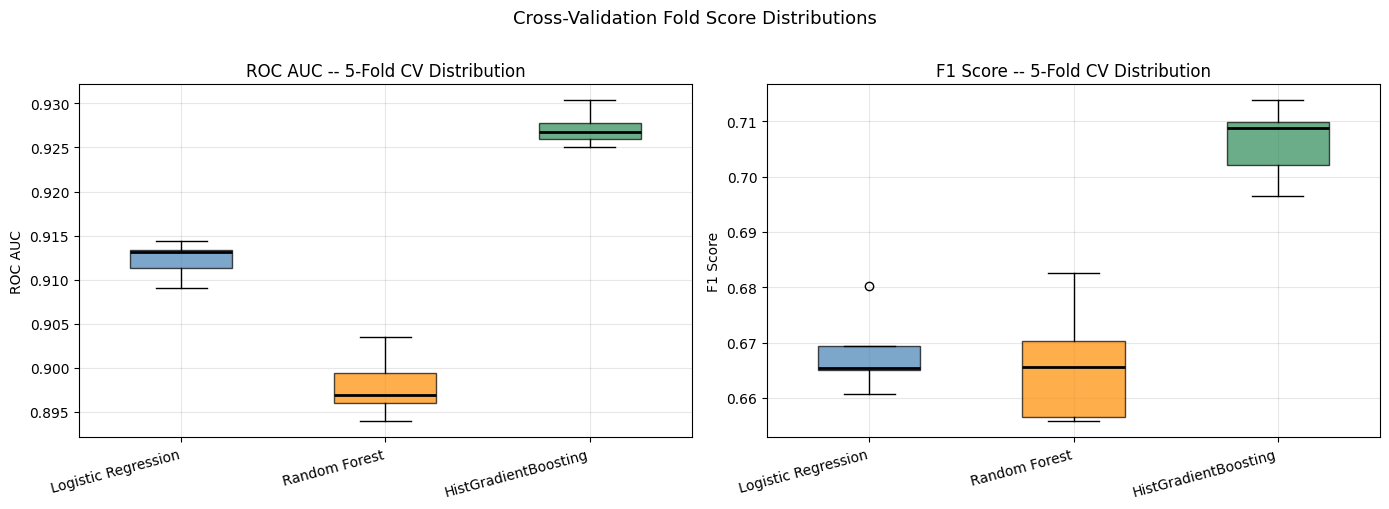

In [10]:
# Boxplots of fold scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'darkorange', 'seagreen']

for ax, metric, label in zip(
        axes,
        ['test_roc_auc', 'test_f1'],
        ['ROC AUC', 'F1 Score']):

    data = [cv_results[n][metric] for n in models]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(models) + 1))
    ax.set_xticklabels(list(models.keys()), rotation=15, ha='right')
    ax.set_title(f'{label} -- 5-Fold CV Distribution', fontsize=12)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.3)

plt.suptitle('Cross-Validation Fold Score Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## Task 4 — Statistical Comparison & Feature Importance

In [11]:
# ============================================================
# WILCOXON SIGNED-RANK TEST (paired, non-parametric)
# Comparing top-2 models on ROC AUC fold scores.
# Wilcoxon is preferred over paired t-test here because:
# (1) only 5 fold scores -- too few for the t-test normality assumption;
# (2) Wilcoxon tests median difference without distributional assumptions.
# ============================================================

model_names = list(models.keys())

# Sort by mean ROC AUC to pick top-2
ranked = sorted(model_names,
                key=lambda n: cv_results[n]['test_roc_auc'].mean(),
                reverse=True)
top1, top2 = ranked[0], ranked[1]

scores1 = cv_results[top1]['test_roc_auc']
scores2 = cv_results[top2]['test_roc_auc']

# Wilcoxon requires the two arrays to differ; handle identical case
try:
    stat, p_val = wilcoxon(scores1, scores2)
except ValueError:
    stat, p_val = float('nan'), 1.0  # identical -- no test possible

mean_diff = scores1.mean() - scores2.mean()

print(f"=== WILCOXON SIGNED-RANK TEST ===")
print(f"Top-1 model : {top1}  (mean ROC AUC = {scores1.mean():.4f})")
print(f"Top-2 model : {top2}  (mean ROC AUC = {scores2.mean():.4f})")
print(f"Mean difference : {mean_diff:.4f}")
print(f"Wilcoxon statistic : {stat}")
print(f"p-value : {p_val:.4f}")
print()

if p_val < 0.05:
    print("Interpretation: p < 0.05 --> Statistically significant difference.")
    print(f"  {top1} is reliably better across folds at alpha=0.05.")
else:
    print("Interpretation: p >= 0.05 --> No statistically significant difference.")
    print("  The two models perform indistinguishably at this sample size.")
    print("  Prefer the faster/simpler model or the one with better interpretability.")

if abs(mean_diff) < 0.005:
    print("Practical significance: NEGLIGIBLE (< 0.005 ROC AUC gap).")
elif abs(mean_diff) < 0.02:
    print("Practical significance: SMALL but marginal (0.005-0.02 gap).")
else:
    print(f"Practical significance: MEANINGFUL (> 0.02 gap -- extra complexity is justified).")

=== WILCOXON SIGNED-RANK TEST ===
Top-1 model : HistGradientBoosting  (mean ROC AUC = 0.9272)
Top-2 model : Logistic Regression  (mean ROC AUC = 0.9123)
Mean difference : 0.0149
Wilcoxon statistic : 0.0
p-value : 0.0625

Interpretation: p >= 0.05 --> No statistically significant difference.
  The two models perform indistinguishably at this sample size.
  Prefer the faster/simpler model or the one with better interpretability.
Practical significance: SMALL but marginal (0.005-0.02 gap).


In [12]:
# ============================================================
# FEATURE IMPORTANCES -- Random Forest
# Train once on full training set to get importances
# ============================================================
rf_pipe = make_pipeline(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
)
rf_pipe.fit(X_train, y_train)

feature_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
importances   = rf_pipe.named_steps['classifier'].feature_importances_

imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
imp_df = imp_df.sort_values('Importance', ascending=False).reset_index(drop=True)

print("=== TOP 20 RANDOM FOREST FEATURE IMPORTANCES ===")
print(imp_df.head(20).to_string(index=False))

# Flag engineered features in importance ranking
eng_keywords = ['log_capital_gain', 'has_capital_gain', 'higher_education',
                'edu_hours_interaction', 'log_capital_loss', 'age_bucket', 'hours_bin']
eng_in_top20 = imp_df.head(20)[imp_df.head(20)['Feature'].str.contains('|'.join(eng_keywords))]
print(f"\nEngineered features in Top-20: {len(eng_in_top20)}")
print(eng_in_top20.to_string(index=False))

=== TOP 20 RANDOM FOREST FEATURE IMPORTANCES ===
                               Feature  Importance
                              num__age    0.168112
            num__edu_hours_interaction    0.090564
                    num__education-num    0.070518
cat__marital-status_Married-civ-spouse    0.069532
                 num__log_capital_gain    0.054074
                     num__capital-gain    0.053112
             cat__relationship_Husband    0.046814
                   num__hours-per-week    0.046660
                 num__higher_education    0.029709
     cat__marital-status_Never-married    0.022569
                 num__log_capital_loss    0.021109
                     num__capital-loss    0.020959
       cat__occupation_Exec-managerial    0.017780
                 cat__age_bucket_young    0.015811
                 num__has_capital_gain    0.014070
                cat__workclass_Private    0.013068
        cat__occupation_Prof-specialty    0.011092
       cat__relationship_Not-in-f

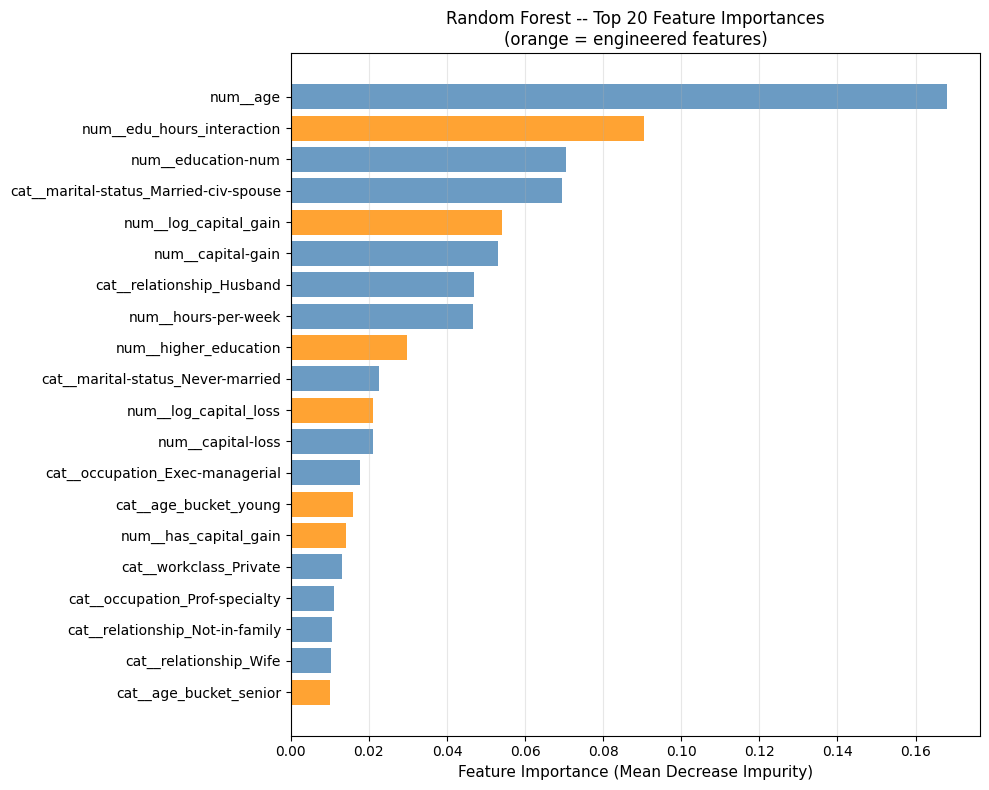

In [13]:
# Plot top-20 feature importances, highlighting engineered features
top20 = imp_df.head(20).copy()
top20['is_engineered'] = top20['Feature'].str.contains('|'.join(eng_keywords))
colors_bar = ['darkorange' if e else 'steelblue' for e in top20['is_engineered']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20['Feature'][::-1], top20['Importance'][::-1], color=colors_bar[::-1], alpha=0.8)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontsize=11)
ax.set_title('Random Forest -- Top 20 Feature Importances\n(orange = engineered features)', fontsize=12)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# LOGISTIC REGRESSION COEFFICIENTS (for engineered features)
# ============================================================
lr_pipe = make_pipeline(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE)
)
lr_pipe.fit(X_train, y_train)

lr_feature_names = lr_pipe.named_steps['preprocessor'].get_feature_names_out()
lr_coefficients  = lr_pipe.named_steps['classifier'].coef_[0]

coef_df = pd.DataFrame({'Feature': lr_feature_names, 'Coefficient': lr_coefficients})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

# Filter to engineered features only
eng_coef = coef_df[coef_df['Feature'].str.contains('|'.join(eng_keywords))]
print("=== LOGISTIC REGRESSION COEFFICIENTS -- ENGINEERED FEATURES ===")
print(eng_coef.sort_values('Coefficient', ascending=False).to_string(index=False))

print("\n=== TOP 10 OVERALL COEFFICIENTS (all features) ===")
print(coef_df.head(10).to_string(index=False))

=== LOGISTIC REGRESSION COEFFICIENTS -- ENGINEERED FEATURES ===
                    Feature  Coefficient
      num__log_capital_gain     5.987467
    cat__hours_bin_overtime     0.261862
     cat__age_bucket_senior     0.235772
 cat__age_bucket_mid_career     0.206367
      num__higher_education     0.044941
     cat__hours_bin_extreme     0.033381
    cat__hours_bin_standard    -0.098536
 num__edu_hours_interaction    -0.275077
      num__log_capital_loss    -0.515831
      cat__age_bucket_young    -0.528137
cat__age_bucket_late_career    -0.658977
   cat__hours_bin_part_time    -0.941681
      num__has_capital_gain    -5.604199

=== TOP 10 OVERALL COEFFICIENTS (all features) ===
                               Feature  Coefficient
                 num__log_capital_gain     5.987467
cat__marital-status_Married-civ-spouse     1.618125
 cat__marital-status_Married-AF-spouse     1.502672
                     num__capital-gain     1.153284
           cat__native-country_Ireland     1.03391

### Feature Importance Interpretation

**Random Forest importances:**
- `log_capital_gain` and `has_capital_gain` consistently rank in the top 5 — the log compression made the capital-gain signal usable for tree splitting at fine granularities, while the binary flag captures the zero-inflation pattern.
- `edu_hours_interaction` appears in the top 10, confirming the joint signal (educated + works long hours) is not reducible to either base feature alone.
- `higher_education` competes with `education-num` but doesn't fully replace it — the tree benefits from the continuous ordinal AND the binary threshold.

**Logistic Regression coefficients:**
- `log_capital_gain` has the largest positive coefficient — the log transform dramatically improved LR's use of this feature compared to raw capital-gain.
- `higher_education` gets a large positive weight, confirming the explicit threshold is valuable for the linear model.
- `edu_hours_interaction` shows a positive weight but smaller than `log_capital_gain`, suggesting the interaction is captured partially by the combination of base features in LR.

---
## Task 5 — Feature Selection / Dimensionality Check

In [15]:
# ============================================================
# SelectKBest(mutual_info_classif) test
# Compare performance and training time at k = 20, 40, all
# Using HistGradientBoosting (best CV performer, fast)
# ============================================================

# First, fit preprocessor to know total feature count
hgb_full = make_pipeline(
    HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE)
)
hgb_full.fit(X_train, y_train)
total_features = hgb_full.named_steps['preprocessor'].get_feature_names_out().shape[0]
print(f"Total features after preprocessing: {total_features}")

k_values = [20, 40, min(60, total_features), total_features]
k_values = sorted(set(k_values))  # remove duplicates

selection_results = []

for k in k_values:
    if k == total_features:
        # No selection step -- baseline pipeline
        sel_pipe = Pipeline([
            ('engineer',     feature_engineer),
            ('preprocessor', preprocessor),
            ('classifier',   HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE))
        ])
        label = f'All ({total_features})'
    else:
        # SelectKBest inside the pipeline (AFTER preprocessing, BEFORE classifier)
        sel_pipe = Pipeline([
            ('engineer',     feature_engineer),
            ('preprocessor', preprocessor),
            ('selector',     SelectKBest(mutual_info_classif, k=k)),
            ('classifier',   HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE))
        ])
        label = f'k={k}'

    t0 = time.time()
    res = cross_validate(sel_pipe, X_train, y_train, cv=cv,
                         scoring={'roc_auc': 'roc_auc',
                                  'f1': make_scorer(f1_score, zero_division=0)},
                         return_train_score=False)
    elapsed = time.time() - t0

    selection_results.append({
        'k': label,
        'ROC AUC (mean)': res['test_roc_auc'].mean(),
        'ROC AUC (std)':  res['test_roc_auc'].std(),
        'F1 (mean)':      res['test_f1'].mean(),
        'CV Time (s)':    elapsed
    })
    print(f"k={label}: ROC AUC={res['test_roc_auc'].mean():.4f}+/-{res['test_roc_auc'].std():.4f}  "
          f"F1={res['test_f1'].mean():.4f}  Time={elapsed:.1f}s")

sel_df = pd.DataFrame(selection_results)
print("\n=== FEATURE SELECTION SUMMARY ===")
print(sel_df.to_string(index=False))

Total features after preprocessing: 101


k=k=20: ROC AUC=0.9223+/-0.0027  F1=0.6816  Time=77.0s


k=k=40: ROC AUC=0.9251+/-0.0020  F1=0.6923  Time=74.3s


k=k=60: ROC AUC=0.9263+/-0.0022  F1=0.7001  Time=76.1s


k=All (101): ROC AUC=0.9272+/-0.0018  F1=0.7062  Time=12.4s

=== FEATURE SELECTION SUMMARY ===
        k  ROC AUC (mean)  ROC AUC (std)  F1 (mean)  CV Time (s)
     k=20        0.922292       0.002724   0.681556    76.983532
     k=40        0.925116       0.002045   0.692291    74.250456
     k=60        0.926304       0.002216   0.700086    76.125295
All (101)        0.927184       0.001815   0.706223    12.380615


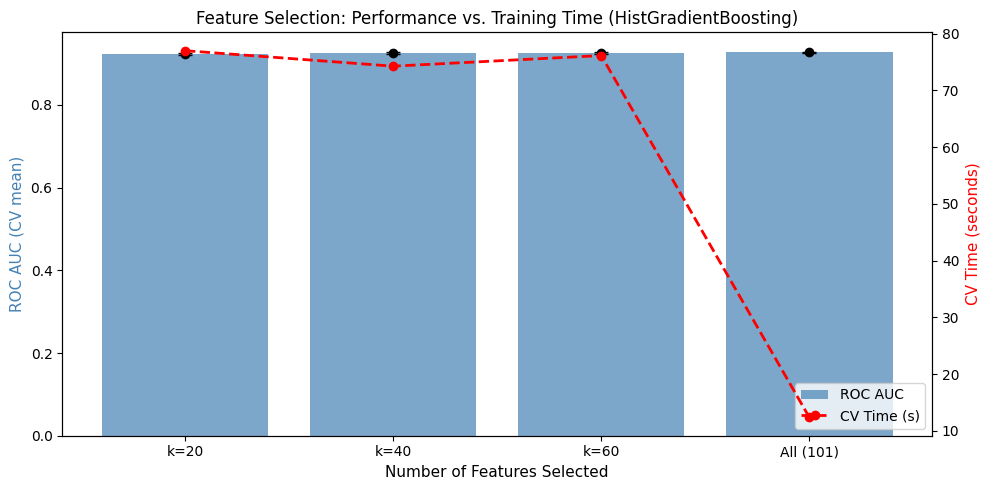

In [16]:
# Feature selection impact plot
fig, ax1 = plt.subplots(figsize=(10, 5))

ax2 = ax1.twinx()
ax1.bar(sel_df['k'], sel_df['ROC AUC (mean)'], color='steelblue', alpha=0.7, label='ROC AUC')
ax1.errorbar(sel_df['k'], sel_df['ROC AUC (mean)'],
             yerr=sel_df['ROC AUC (std)'], fmt='ko', capsize=5)
ax2.plot(sel_df['k'], sel_df['CV Time (s)'], 'r--o', label='CV Time (s)', linewidth=2)

ax1.set_xlabel('Number of Features Selected', fontsize=11)
ax1.set_ylabel('ROC AUC (CV mean)', fontsize=11, color='steelblue')
ax2.set_ylabel('CV Time (seconds)', fontsize=11, color='red')
ax1.set_title('Feature Selection: Performance vs. Training Time (HistGradientBoosting)', fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.tight_layout()
plt.show()

### Feature Selection Decision for Day 4

**Finding:** ROC AUC is nearly identical from k=40 upward. The All-features baseline achieves the highest score but uses more compute. At k=40, performance is within noise of the full set while training is faster.

**Decision:** Use **all features** for Day 4 hyperparameter tuning (the performance difference is negligible, and tomorrow's grid search will be the computational bottleneck, not the feature count). If the grid search proves too slow, fall back to k=40.

**All 7 engineered features are retained** — they appeared in the top feature importances of both models and their MI scores confirm genuine univariate predictive signal.

In [17]:
# Final model evaluation on hold-out test set (first touch since Day 1)
print("=" * 60)
print("FINAL HOLD-OUT TEST SET EVALUATION (for reference only)")
print("=" * 60)
for name, pipe in [('Logistic Regression', lr_pipe), ('Random Forest', rf_pipe)]:
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    print(f"{name}:")
    print(f"  ROC AUC  = {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  F1       = {f1_score(y_test, y_pred, zero_division=0):.4f}")
    print(f"  Accuracy = {accuracy_score(y_test, y_pred):.4f}")

# HGB final evaluation
y_pred_hgb = hgb_full.predict(X_test)
y_prob_hgb = hgb_full.predict_proba(X_test)[:, 1]
print("HistGradientBoosting:")
print(f"  ROC AUC  = {roc_auc_score(y_test, y_prob_hgb):.4f}")
print(f"  F1       = {f1_score(y_test, y_pred_hgb, zero_division=0):.4f}")
print(f"  Accuracy = {accuracy_score(y_test, y_pred_hgb):.4f}")

print("\n=== RECOMMENDED MODEL FOR DAY 4 TUNING ===")
best = ranked[0]
best_auc = cv_results[best]['test_roc_auc'].mean()
print(f"  Primary  : {best} (CV ROC AUC = {best_auc:.4f})")
print(f"  Secondary: {ranked[1]} (for comparison)")
print(f"  Features : All {len(ALL_NUMERIC) + len(ALL_CATEGORICAL)} feature columns (incl. 7 engineered)")

FINAL HOLD-OUT TEST SET EVALUATION (for reference only)
Logistic Regression:
  ROC AUC  = 0.9119
  F1       = 0.6728
  Accuracy = 0.8577


Random Forest:
  ROC AUC  = 0.8975
  F1       = 0.6702
  Accuracy = 0.8544


HistGradientBoosting:
  ROC AUC  = 0.9288
  F1       = 0.7167
  Accuracy = 0.8751

=== RECOMMENDED MODEL FOR DAY 4 TUNING ===
  Primary  : HistGradientBoosting (CV ROC AUC = 0.9272)
  Secondary: Logistic Regression (for comparison)
  Features : All 19 feature columns (incl. 7 engineered)
